# Extra datasets (leftover families)

Personal notes: `eda/talk/N_extra.md`.

This notebook is coverage, not the main story. Main story is guide, then Wei, then exposure, then counties, then payams, then drivers.

Here: Dartmouth discharge, Lake Albert, ERA5 runoff, health facilities, ET file count, national GDP.

Payams: `admin3_payams.ipynb`. OSM: `osm_malakal.ipynb`.
Skipped: adminlines/points (drawing helpers only).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point
import rasterio

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "extra"
OUT.mkdir(parents=True, exist_ok=True)

BBOX = {"lat_min": 5.5, "lat_max": 10.5, "lon_min": 30.5, "lon_max": 34.5}
YEAR = 2023  # health overlay uses this flood year


## Dartmouth discharge
Monthly river discharge at gauging stations. Few points; useful as coarse driver, not local AA map.

In [2]:
# station list + how long each discharge series is
info = pd.read_excel(DATA / "Darthmouth Flood Observatory" / "information.xlsx")
display(info.head())
print("stations", len(info))
print(info[["area id", "country", "latitude", "longitude"]].head(20) if set(["area id","country","latitude","longitude"]).issubset(info.columns) else info.columns)

# load all discharge series lengths
rows = []
for pid in info["area id"].dropna().astype(int):
    path = DATA / "Darthmouth Flood Observatory" / f"{pid}_discharge.csv"
    if not path.exists():
        continue
    d = pd.read_csv(path)
    d["Date"] = pd.to_datetime(d["Date"])
    rows.append({
        "area_id": pid,
        "n": len(d),
        "date_min": d["Date"].min(),
        "date_max": d["Date"].max(),
        "discharge_mean": d["Discharge (m3/s)"].mean() if "Discharge (m3/s)" in d.columns else d.iloc[:,1].mean(),
    })
disc = pd.DataFrame(rows)
disc.to_csv(OUT / "discharge_station_summary.csv", index=False)
disc


,station nr,area id,Country,latitude,longitude
0,334,100205,South Sudan,9.6,31.6
1,224,1541,Sudan,12.4,32.8
2,225,1542,Sudan,13.9,32.4
3,226,1543,Sudan,14.9,32.2
4,227,1544,Sudan,13.1,33.9


stations 13
Index(['station nr', 'area id', 'Country', 'latitude', 'longitude'], dtype='str')


,area_id,n,date_min,date_max,discharge_mean
0,100205,10366,1998-01-01,2026-05-19,5401.827843
1,1541,10366,1998-01-01,2026-05-19,6616.260742
2,1542,10366,1998-01-01,2026-05-19,5758.885077
3,1543,10366,1998-01-01,2026-05-19,6437.218353
4,1544,10366,1998-01-01,2026-05-19,1924.507143
5,1545,10366,1998-01-01,2026-05-19,2251.203502
6,1547,10366,1998-01-01,2026-05-19,6617.711532
7,1548,10366,1998-01-01,2026-05-19,9333.178887
8,11808,10366,1998-01-01,2026-05-19,11035.809331
9,11842,10366,1998-01-01,2026-05-19,10342.875929


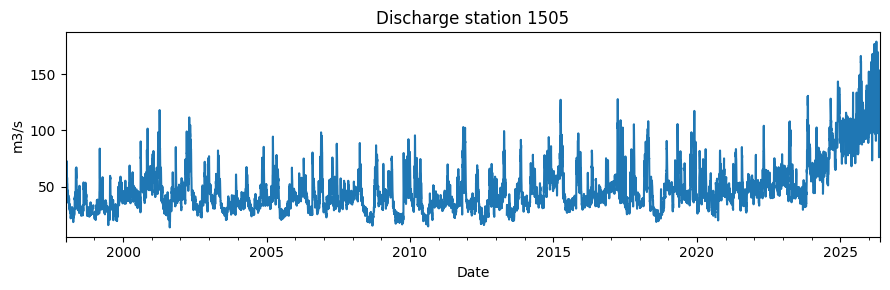

In [3]:
# pick a station that has data until recently (not a local SSD map)
# plot one station with most recent data inside/near SSD if possible
# pick station with max date_max
pid = int(disc.sort_values("date_max").iloc[-1]["area_id"])
d = pd.read_csv(DATA / "Darthmouth Flood Observatory" / f"{pid}_discharge.csv")
d["Date"] = pd.to_datetime(d["Date"])
col = "Discharge (m3/s)" if "Discharge (m3/s)" in d.columns else d.columns[1]
d = d.set_index("Date").sort_index()
fig, ax = plt.subplots(figsize=(9, 3))
d[col].plot(ax=ax)
ax.set_title(f"Discharge station {pid}")
ax.set_ylabel("m3/s")
fig.tight_layout()
fig.savefig(OUT / "01_discharge_example.png", dpi=140)
plt.show()


## Lake Albert
Upstream / connected Nile system. Different file format (.nc) from Victoria/Kyoga txt.

<xarray.Dataset> Size: 71kB
Dimensions:      (time: 850)
Dimensions without coordinates: time
Data variables:
    datetime     (time) <U19 65kB ...
    water_level  (time) float32 3kB ...
    error        (time) float32 3kB ...
Attributes: (12/14)
    dahiti_id:      85
    dataset:        water-level-altimetry
    target_name:    Albert, Lake
    location:       None
    country:        Democratic Republic of the Congo
    continent:      Africa
    ...             ...
    geoid:          -15.0661
    software:       8.0
    institution:    DGFI-TUM
    source:         DAHITI
    url:            https://dahiti.dgfi.tum.de/85/
    creation_date:  2026-05-27 11:44:36


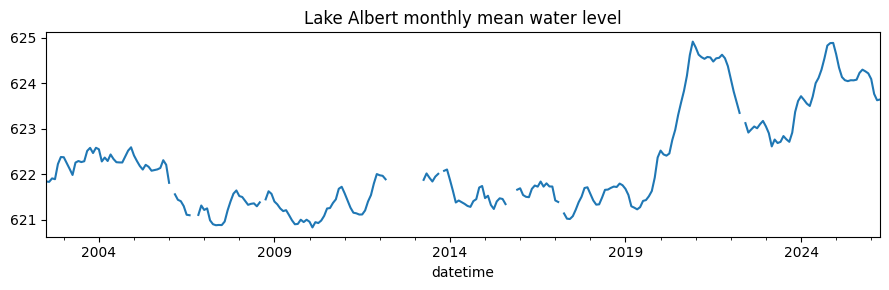

datetime
2025-12-01    624.219995
2026-01-01    624.094340
2026-02-01    623.768799
2026-03-01    623.630025
2026-04-01    623.646647
Freq: MS, Name: water_level, dtype: float64


In [4]:
# albert nc stores time as a variable, not a dimension. easy to miss
ds = xr.open_dataset(DATA / "Water levels lakes" / "water_level_altimetry_Albert.nc")
print(ds)
# datetime is a data var here, not a coordinate
df = pd.DataFrame({
    "datetime": pd.to_datetime(ds["datetime"].values.astype(str)),
    "water_level": ds["water_level"].values.astype(float),
}).dropna().set_index("datetime").sort_index()
albert_m = df["water_level"].resample("MS").mean()
albert_m.to_csv(OUT / "albert_monthly.csv", header=["water_level"])
fig, ax = plt.subplots(figsize=(9, 3))
albert_m.plot(ax=ax)
ax.set_title("Lake Albert monthly mean water level")
fig.tight_layout()
fig.savefig(OUT / "02_albert_monthly.png", dpi=140)
plt.show()
ds.close()
print(albert_m.tail())


## ERA5 runoff
Drivers notebook used precipitation (tp). Runoff (ro) is the water leaving the surface grid cell.

runoff 2022


runoff 2023


runoff 2024
corr flood vs runoff -0.4396146948325874


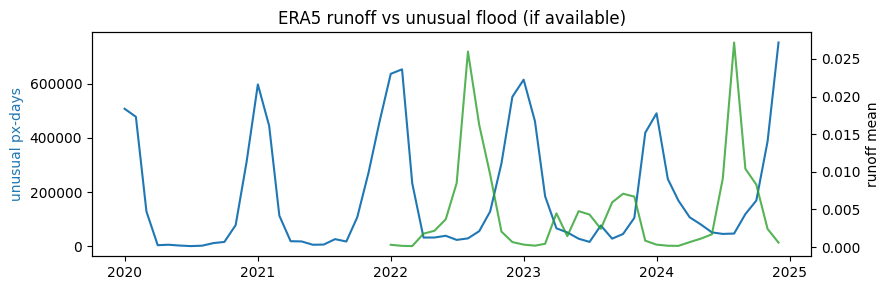

,date,ro_mm_mean
0,2022-01-01,0.000303
1,2022-02-01,0.000165
2,2022-03-01,0.000131
3,2022-04-01,0.001782
4,2022-05-01,0.002168


In [5]:
# ro = runoff in the same ERA5 files as rain (tp)
rows = []
for year in [2022, 2023, 2024]:
    path = DATA / "rainfall and runoff" / f"ERA5_{year}.nc"
    ds = xr.open_dataset(path)
    ro = ds["ro"]
    lat_name = "latitude" if "latitude" in ro.coords else "lat"
    lon_name = "longitude" if "longitude" in ro.coords else "lon"
    time_name = "valid_time" if "valid_time" in ro.coords else "time"
    lat0 = float(ro[lat_name][0])
    lat1 = float(ro[lat_name][-1])
    lat_slice = slice(BBOX["lat_max"], BBOX["lat_min"]) if lat0 > lat1 else slice(BBOX["lat_min"], BBOX["lat_max"])
    ro_s = ro.sel({lat_name: lat_slice, lon_name: slice(BBOX["lon_min"], BBOX["lon_max"])})
    monthly = (ro_s.mean(dim=[lat_name, lon_name]) * 1000).resample({time_name: "MS"}).mean()
    for t, val in zip(monthly[time_name].values, monthly.values):
        rows.append({"date": pd.to_datetime(t), "ro_mm_mean": float(val)})
    ds.close()
    print("runoff", year)
ro_df = pd.DataFrame(rows).drop_duplicates("date").sort_values("date")
ro_df.to_csv(OUT / "era5_runoff_monthly.csv", index=False)

# compare to flood monthly if exists
flood_path = ROOT / "eda" / "outputs" / "drivers" / "unusual_flood_monthly.csv"
fig, ax1 = plt.subplots(figsize=(9, 3))
if flood_path.exists():
    flood = pd.read_csv(flood_path, parse_dates=["date"]).set_index("date")
    ax1.plot(flood.index, flood["unusual_pixel_days"], color="C0")
    ax1.set_ylabel("unusual px-days", color="C0")
    ax2 = ax1.twinx()
    ax2.plot(ro_df["date"], ro_df["ro_mm_mean"], color="C2", alpha=0.8)
    ax2.set_ylabel("runoff mean")
    # corr on overlap
    m = flood.join(ro_df.set_index("date"), how="inner")
    if len(m) > 6:
        print("corr flood vs runoff", m["unusual_pixel_days"].corr(m["ro_mm_mean"]))
else:
    ax1.plot(ro_df["date"], ro_df["ro_mm_mean"])
ax1.set_title("ERA5 runoff vs unusual flood (if available)")
fig.tight_layout()
fig.savefig(OUT / "03_runoff_vs_flood.png", dpi=140)
plt.show()
ro_df.head()


## Health facilities
Count facilities in Jonglei/Upper Nile and how many sit inside/near unusual flood pixels (2023 sample).

SSD facilities 1747
['FID', 'Country', 'Admin1', 'Facility_n', 'Facility_t', 'Ownership', 'Lat', 'Long', 'LL_source', 'geometry']
adm1_name
Jonglei       157
Upper Nile    142
Name: count, dtype: int64


,n_facilities,n_near_flood,frac_near_flood
adm1_name,,,
Jonglei,157,54,0.343949
Upper Nile,142,43,0.302817


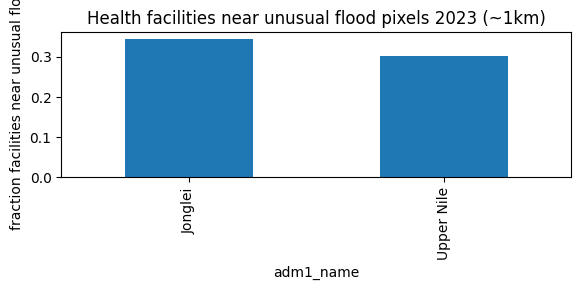

In [6]:
# ~0.01 deg is about 1 km. this is a coarse 'clinic near water' flag, not a road model
hf = gpd.read_file(DATA / "health facilities" / "Sub-Saharan_public_health_facilities.geojson")
# SSD only
if "Country" in hf.columns:
    hf = hf[hf["Country"].str.contains("South Sudan", case=False, na=False)].copy()
print("SSD facilities", len(hf))
print(hf.columns.tolist())

admin1 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin1.geojson")
focus = admin1[admin1["adm1_name"].isin(["Jonglei", "Upper Nile"])]
hf = hf.to_crs(admin1.crs)
hf_j = gpd.sjoin(hf, focus[["adm1_name", "geometry"]], how="inner", predicate="within")
print(hf_j["adm1_name"].value_counts())

# unusual flood points 2023 sample
parts = []
for tile in ["h20v08", "h21v08"]:
    p = DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_{YEAR}.parquet"
    parts.append(pd.read_parquet(p, columns=["lat", "lon"]))
u = pd.concat(parts, ignore_index=True)
m = (u.lat.between(BBOX["lat_min"], BBOX["lat_max"])) & (u.lon.between(BBOX["lon_min"], BBOX["lon_max"]))
u = u.loc[m].drop_duplicates().sample(min(40000, m.sum()), random_state=0)

# facility within ~0.01 deg (~1km) of any flood point: coarse buffer via round grid
flood_keys = set(zip((u.lon * 100).round().astype(int), (u.lat * 100).round().astype(int)))
lon_col = "Long" if "Long" in hf_j.columns else ("lon" if "lon" in hf_j.columns else None)
lat_col = "Lat" if "Lat" in hf_j.columns else ("lat" if "lat" in hf_j.columns else None)
if lon_col is None:
    # geometry
    hf_j["lon"] = hf_j.geometry.x
    hf_j["lat"] = hf_j.geometry.y
    lon_col, lat_col = "lon", "lat"

near = []
for _, r in hf_j.iterrows():
    key = (int(round(r[lon_col] * 100)), int(round(r[lat_col] * 100)))
    # check neighborhood 3x3 cells (~1km)
    hit = False
    for dx in range(-1, 2):
        for dy in range(-1, 2):
            if (key[0] + dx, key[1] + dy) in flood_keys:
                hit = True
                break
        if hit:
            break
    near.append(hit)
hf_j = hf_j.copy()
hf_j["near_unusual_2023"] = near
summary = hf_j.groupby("adm1_name").agg(n_facilities=("near_unusual_2023", "size"), n_near_flood=("near_unusual_2023", "sum"))
summary["frac_near_flood"] = summary["n_near_flood"] / summary["n_facilities"]
summary.to_csv(OUT / "health_near_unusual_2023.csv")
display(summary)

fig, ax = plt.subplots(figsize=(6, 3))
summary["frac_near_flood"].plot(kind="bar", ax=ax)
ax.set_ylabel("fraction facilities near unusual flood")
ax.set_title("Health facilities near unusual flood pixels 2023 (~1km)")
fig.tight_layout()
fig.savefig(OUT / "04_health_near_flood.png", dpi=140)
plt.show()


## Evapotranspiration (sample)
Thousands of daily files. For EDA we only check one processed year pattern / file count, not full ET pipeline.

ET nc files 9497


2016    366
2017    365
2018    365
2019    365
2020      9
2021    375
2022    315
2023    365
2024    366
2025    365
dtype: int64

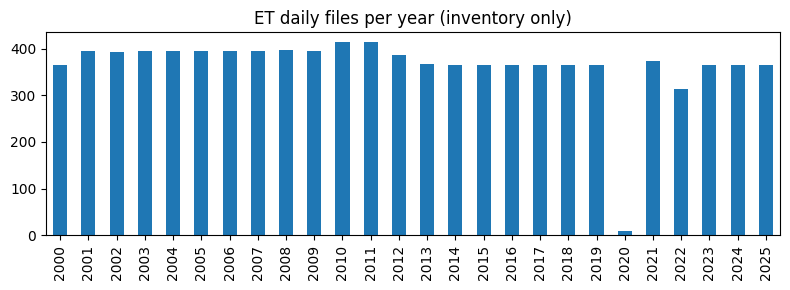

In [7]:
# do not open all daily files. just count them so we know ET exists
et_dir = DATA / "evapotranspiration"
files = sorted(et_dir.glob("*.nc")) if et_dir.exists() else []
# also nested
if not files:
    files = sorted(et_dir.rglob("*.nc"))
print("ET nc files", len(files))
if files:
    years = {}
    for f in files:
        # try parse year from name
        for y in range(2000, 2027):
            if str(y) in f.name:
                years[y] = years.get(y, 0) + 1
                break
    et_years = pd.Series(years).sort_index()
    display(et_years.tail(10))
    et_years.to_csv(OUT / "et_file_counts_by_year.csv", header=["n_files"])
    fig, ax = plt.subplots(figsize=(8, 3))
    et_years.plot(kind="bar", ax=ax)
    ax.set_title("ET daily files per year (inventory only)")
    fig.tight_layout()
    fig.savefig(OUT / "05_et_inventory.png", dpi=140)
    plt.show()
else:
    print("no ET files found")


## GDP (national only)
Not local. Keep as background series, not AA targeting input.

n indicators 1486
['Intentional homicides, male (per 100,000 male)', 'Battle-related deaths (number of people)', 'High-technology exports (current US$)', 'Merchandise exports to low- and middle-income economies within region (% of total merchandise exports)', 'Merchandise exports to low- and middle-income economies in South Asia (% of total merchandise exports)', 'Merchandise exports to low- and middle-income economies in East Asia & Pacific (% of total merchandise exports)', 'Merchandise exports to economies in the Arab World (% of total merchandise exports)', 'ICT goods exports (% of total goods exports)', 'Export unit value index (2015 = 100)', 'Travel services (% of commercial service imports)', 'Import value index (2015 = 100)', 'Merchandise imports from low- and middle-income economies in Sub-Saharan Africa (% of total merchandise imports)', 'Merchandise imports from low- and middle-income economies in Europe & Central Asia (% of total merchandise imports)', 'Merchandise imports 

<>:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
/tmp/ipykernel_79402/185821080.py:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  pick = sub[sub["Indicator Name"].str.contains("GDP \(current US\$\)", regex=True, na=False)]


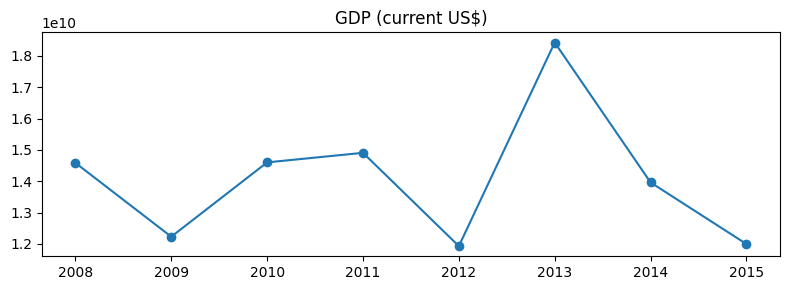

2011    1.490731e+10
2012    1.193147e+10
2013    1.842647e+10
2014    1.396221e+10
2015    1.199780e+10
dtype: float64

In [8]:
# national GDP only. skiprows=4 because world bank csv has junk header rows
gdp_path = list((DATA / "GDP").glob("*.csv"))[0]
# world bank csv often has header rows
raw = pd.read_csv(gdp_path, skiprows=4)
# filter South Sudan GDP indicators
sub = raw[raw["Country Name"].str.contains("South Sudan", case=False, na=False)]
# prefer GDP current US$ or similar
inds = sub["Indicator Name"].unique().tolist()
print("n indicators", len(inds))
print(inds[:15])
# pick first GDP (current US$) if exists
pick = sub[sub["Indicator Name"].str.contains("GDP \(current US\$\)", regex=True, na=False)]
if pick.empty:
    pick = sub.head(1)
row = pick.iloc[0]
years = [c for c in pick.columns if c.isdigit()]
series = pd.Series({int(y): row[y] for y in years if pd.notna(row[y])}).sort_index()
series = series.loc[2000:2025] if len(series) else series
series.to_csv(OUT / "gdp_ssd_series.csv", header=["value"])
fig, ax = plt.subplots(figsize=(8, 3))
series.plot(ax=ax, marker="o")
ax.set_title(str(row["Indicator Name"])[:60])
fig.tight_layout()
fig.savefig(OUT / "06_gdp.png", dpi=140)
plt.show()
series.tail()


## Still skipped on purpose

- **adminlines / adminpoints:** helpers for drawing borders, not analysis
- **full ET processing:** thousands of daily files; inventory only

Payams and OSM have their own notebooks. GDP is national, so it will never target a county.
